# Employee Attrition Analysis Project

In [2]:
import pandas as pd

df = pd.read_csv("../data/WA_Fn-UseC_-HR-Employee-Attrition.csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
df['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

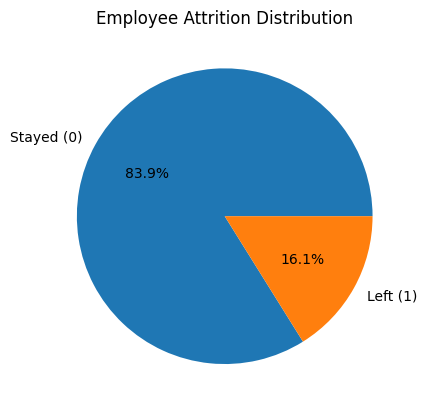

In [4]:
import matplotlib.pyplot as plt

df['Attrition'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    labels=['Stayed (0)', 'Left (1)']
)

plt.title("Employee Attrition Distribution")
plt.show()

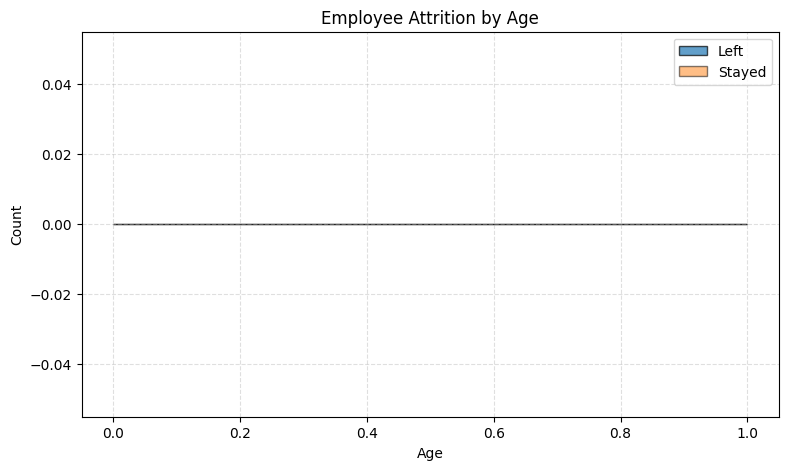

In [5]:
left = df[df['Attrition']==1]['Age']
stayed = df[df['Attrition']==0]['Age']

plt.figure(figsize=(9,5))

plt.hist(left, bins=15, alpha=0.7, label='Left', edgecolor='black')
plt.hist(stayed, bins=15, alpha=0.5, label='Stayed', edgecolor='black')

plt.title("Employee Attrition by Age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)

plt.show()

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
import pandas as pd

df = pd.read_csv("../data/WA_Fn-UseC_-HR-Employee-Attrition.csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [8]:
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

In [9]:
df['Attrition'].value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

C:\Users\ASUS\AppData\Local\Temp\ipykernel_18332\3221439197.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


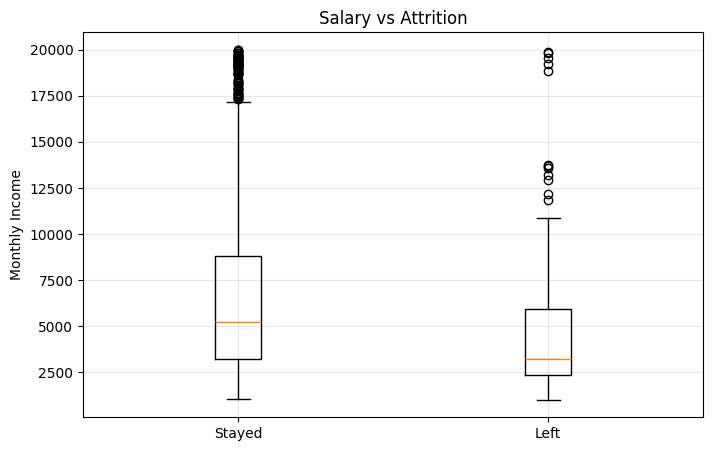

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.boxplot([
    df[df['Attrition']==0]['MonthlyIncome'],
    df[df['Attrition']==1]['MonthlyIncome']
],
labels=['Stayed', 'Left'])

plt.title("Salary vs Attrition")
plt.ylabel("Monthly Income")
plt.grid(alpha=0.3)

plt.show()

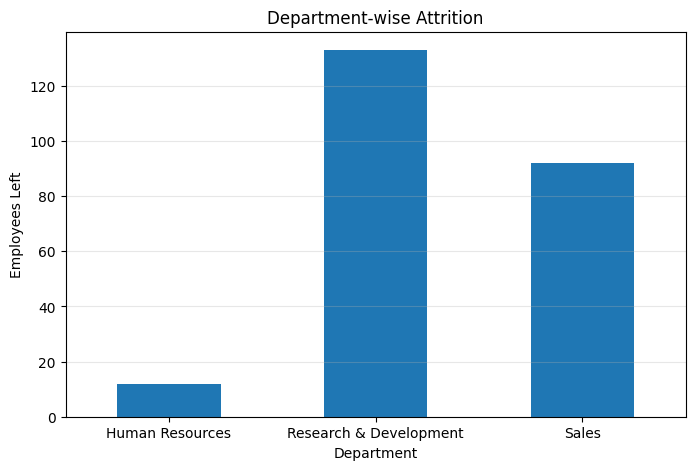

In [11]:
dept_attrition = df.groupby('Department')['Attrition'].sum()

plt.figure(figsize=(8,5))

dept_attrition.plot(kind='bar')

plt.title("Department-wise Attrition")
plt.xlabel("Department")
plt.ylabel("Employees Left")

plt.xticks(rotation=0)

plt.grid(axis='y', alpha=0.3)

plt.show()

## 5. Machine Learning - Employee Attrition Prediction

In [12]:
print(df['Attrition'].value_counts())

print("\nTarget Variable:")
print("0 = Stayed")
print("1 = Left")

Attrition
0    1233
1     237
Name: count, dtype: int64

Target Variable:
0 = Stayed
1 = Left


In [13]:
df.dtypes

Age                         int64
Attrition                   int64
BusinessTravel                str
DailyRate                   int64
Department                    str
DistanceFromHome            int64
Education                   int64
EducationField                str
EmployeeCount               int64
EmployeeNumber              int64
EnvironmentSatisfaction     int64
Gender                        str
HourlyRate                  int64
JobInvolvement              int64
JobLevel                    int64
JobRole                       str
JobSatisfaction             int64
MaritalStatus                 str
MonthlyIncome               int64
MonthlyRate                 int64
NumCompaniesWorked          int64
Over18                        str
OverTime                      str
PercentSalaryHike           int64
PerformanceRating           int64
RelationshipSatisfaction    int64
StandardHours               int64
StockOptionLevel            int64
TotalWorkingYears           int64
TrainingTimesL

In [14]:
categorical_cols = df.select_dtypes(include='object').columns

print(categorical_cols)

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'Over18', 'OverTime'],
      dtype='str')


C:\Users\ASUS\AppData\Local\Temp\ipykernel_18332\1616883611.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns


In [16]:
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Program Files\Python314\python.exe -m pip install --upgrade pip


In [20]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

df.head()

ModuleNotFoundError: No module named 'sklearn'

In [18]:
import sys

print(sys.executable)

c:\Users\ASUS\AppData\Local\Programs\Python\Python311\python.exe


In [19]:
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Program Files\Python314\python.exe -m pip install --upgrade pip
